# Deep Learning — Homework 1
## Introduction, Optimization, and Convolutional Neural Networks

This notebook implements **all required parts** of Homework 1 using **PyTorch**:
- Problem 1: MLPs, activation functions, XOR
- Problem 2: optimizers, vanishing gradients, regularization
- Problem 3: CIFAR-10 CNN, architecture comparison, learned-feature visualization

The notebook follows the assignment specifications and is reproducible with fixed random seeds.


In [ ]:


import time, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "./data"
BATCH_SIZE = 128
NUM_WORKERS = 2

def set_seed(seed=SEED):
    """Re-seed all RNGs. Called before every model so each experiment is
    reproducible on its own, independent of the order cells were run in."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


Device: cpu


# Problem 1 — Implementing and Training MLPs

## Part A
Required architecture: **784 → 128 → 64 → 10**, with a selectable activation function and softmax output.


In [ ]:
# MNIST
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_mnist = datasets.MNIST(DATA_DIR, train=True, download=True, transform=mnist_transform)
test_mnist = datasets.MNIST(DATA_DIR, train=False, download=True, transform=mnist_transform)

train_loader = DataLoader(train_mnist, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_mnist, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_mnist), len(test_mnist))


100%|██████████| 9.91M/9.91M [00:07<00:00, 1.39MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 159kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 236kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.37MB/s]

60000 10000


In [ ]:
class FlexibleMLP(nn.Module):
    """Flexible MLP: arbitrary hidden sizes, ReLU / Sigmoid / Tanh, optional dropout."""
    def __init__(self, input_dim, hidden_dims, output_dim, activation="relu", dropout=0.0):
        super().__init__()
        activations = {"relu": nn.ReLU, "sigmoid": nn.Sigmoid, "tanh": nn.Tanh}
        if activation.lower() not in activations:
            raise ValueError("activation must be relu, sigmoid, or tanh")

        layers = [nn.Flatten()]
        prev = input_dim
        for hidden in hidden_dims:
            layers.append(nn.Linear(prev, hidden))
            layers.append(activations[activation.lower()]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hidden
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):

        return self.network(x)

    def predict_proba(self, x):
        """Softmax output of the network (class probabilities that sum to 1)."""
        self.eval()
        with torch.no_grad():
            return torch.softmax(self.forward(x), dim=1)

def accuracy(model, loader):
    """Accuracy of `model` on `loader` (model is put in eval mode)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def train_model(model, loader, epochs=10, optimizer=None, criterion=None,
                test_loader=None, track_gradients=False):
    """Train for `epochs`. history["train_time"] measures ONLY the optimisation loop
    (evaluation on train/test sets is excluded), so timings of different runs are comparable."""
    model.to(DEVICE)
    criterion = criterion or nn.CrossEntropyLoss()
    optimizer = optimizer or optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "test_acc": [], "train_time": []}
    grad_history = {}

    for epoch in range(epochs):
        start = time.time()
        model.train()
        running_loss, n = 0.0, 0

        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()

            if track_gradients:
                for name, p in model.named_parameters():
                    if "weight" in name and p.grad is not None:
                        grad_history.setdefault(name, []).append(p.grad.detach().abs().mean().item())

            optimizer.step()
            running_loss += loss.item() * y.size(0)
            n += y.size(0)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()                  # wait for GPU before stopping the clock
        history["train_time"].append(time.time() - start)   # <- training time only

        epoch_loss = running_loss / n
        history["loss"].append(epoch_loss)
        history["train_acc"].append(accuracy(model, loader))
        history["test_acc"].append(accuracy(model, test_loader) if test_loader else np.nan)

        print(f"Epoch {epoch+1:02d}/{epochs} | loss={epoch_loss:.4f} | "
              f"train_acc={history['train_acc'][-1]:.4f} | test_acc={history['test_acc'][-1]:.4f}")

    return history, grad_history

# ---- Problem 1A: 784-128-64-10 MLP with ReLU on MNIST
set_seed(SEED)
mlp_relu = FlexibleMLP(784, [128, 64], 10, activation="relu")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_relu.parameters(), lr=1e-3)

history_relu, _ = train_model(
    mlp_relu, train_loader, epochs=10,
    optimizer=optimizer, criterion=criterion, test_loader=test_loader
)
training_time = sum(history_relu["train_time"])

print("Final training accuracy:", history_relu["train_acc"][-1])
print("Final test accuracy:", history_relu["test_acc"][-1])
print("Training time (s):", round(training_time, 2))


xb, _ = next(iter(test_loader))
probs = mlp_relu.predict_proba(xb[:5].to(DEVICE))
print("Softmax rows sum to 1:", probs.sum(dim=1).cpu().numpy().round(4))


Epoch 01/10 | loss=0.3153 | train_acc=0.9555 | test_acc=0.9528
Epoch 02/10 | loss=0.1279 | train_acc=0.9715 | test_acc=0.9646
Epoch 03/10 | loss=0.0899 | train_acc=0.9803 | test_acc=0.9709
Epoch 04/10 | loss=0.0679 | train_acc=0.9821 | test_acc=0.9725
Epoch 05/10 | loss=0.0542 | train_acc=0.9875 | test_acc=0.9740
Epoch 06/10 | loss=0.0441 | train_acc=0.9893 | test_acc=0.9750
Epoch 07/10 | loss=0.0376 | train_acc=0.9903 | test_acc=0.9766
Epoch 08/10 | loss=0.0298 | train_acc=0.9925 | test_acc=0.9744
Epoch 09/10 | loss=0.0252 | train_acc=0.9952 | test_acc=0.9791
Epoch 10/10 | loss=0.0224 | train_acc=0.9923 | test_acc=0.9767
Final training accuracy: 0.9922666666666666
Final test accuracy: 0.9767
Training time (s): 26.28
Softmax rows sum to 1: [1. 1. 1. 1. 1.]


## Part B — Activation Function Comparison

The same **784 → 128 → 64 → 10** architecture is trained with ReLU, Sigmoid, and Tanh. The required shared training-loss graph and final test-accuracy table are produced below.


In [ ]:
activation_histories = {}
activation_results = []

for act in ["relu", "sigmoid", "tanh"]:
    print("\nTraining:", act)
    set_seed(SEED)
    model = FlexibleMLP(784, [128, 64], 10, activation=act)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    hist, _ = train_model(model, train_loader, epochs=10,
                          optimizer=opt, criterion=nn.CrossEntropyLoss(),
                          test_loader=test_loader)
    activation_histories[act] = hist
    activation_results.append({
        "Activation": act,
        "Final Train Accuracy": hist["train_acc"][-1],
        "Final Test Accuracy": hist["test_acc"][-1],
        "Training Time (s)": sum(hist["train_time"])
    })

activation_df = pd.DataFrame(activation_results)
activation_df



Training: relu
Epoch 01/10 | loss=0.3153 | train_acc=0.9555 | test_acc=0.9528
Epoch 02/10 | loss=0.1279 | train_acc=0.9715 | test_acc=0.9646
Epoch 03/10 | loss=0.0899 | train_acc=0.9803 | test_acc=0.9709
Epoch 04/10 | loss=0.0679 | train_acc=0.9821 | test_acc=0.9725
Epoch 05/10 | loss=0.0542 | train_acc=0.9875 | test_acc=0.9740
Epoch 06/10 | loss=0.0441 | train_acc=0.9893 | test_acc=0.9750
Epoch 07/10 | loss=0.0376 | train_acc=0.9903 | test_acc=0.9766
Epoch 08/10 | loss=0.0298 | train_acc=0.9925 | test_acc=0.9744
Epoch 09/10 | loss=0.0252 | train_acc=0.9952 | test_acc=0.9791
Epoch 10/10 | loss=0.0224 | train_acc=0.9923 | test_acc=0.9767

Training: sigmoid
Epoch 01/10 | loss=0.7534 | train_acc=0.9286 | test_acc=0.9292
Epoch 02/10 | loss=0.2231 | train_acc=0.9538 | test_acc=0.9503
Epoch 03/10 | loss=0.1519 | train_acc=0.9678 | test_acc=0.9598
Epoch 04/10 | loss=0.1136 | train_acc=0.9755 | test_acc=0.9655
Epoch 05/10 | loss=0.0891 | train_acc=0.9822 | test_acc=0.9686
Epoch 06/10 | loss=0

,Activation,Final Train Accuracy,Final Test Accuracy,Training Time (s)
0,relu,0.992267,0.9767,25.258172
1,sigmoid,0.995200,0.9758,25.438998
2,tanh,0.995733,0.9777,25.691176


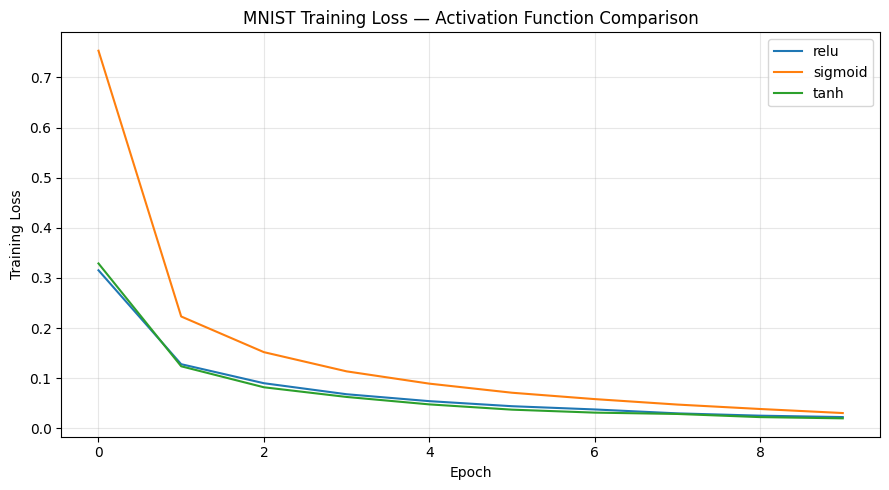

,Activation,Final Train Accuracy,Final Test Accuracy,Training Time (s)
0,relu,0.9923,0.9767,25.26
1,sigmoid,0.9952,0.9758,25.44
2,tanh,0.9957,0.9777,25.69


In [ ]:
plt.figure(figsize=(9, 5))
for act, hist in activation_histories.items():
    plt.plot(hist["loss"], label=act)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MNIST Training Loss — Activation Function Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p1b_activation_loss.png", dpi=200)
plt.show()

activation_df.style.format({
    "Final Train Accuracy": "{:.4f}",
    "Final Test Accuracy": "{:.4f}",
    "Training Time (s)": "{:.2f}"
})


### Brief analysis

After running the notebook, use the generated table and loss curves to identify the activation with the highest final test accuracy. ReLU typically provides strong optimization because its gradient does not saturate for positive inputs, while sigmoid and tanh can suffer more from saturation. The exact ranking should be based on the measured results from this run rather than assumed in advance.


## Part C — XOR

The network uses 2 input features, one hidden layer with 4 neurons, and one sigmoid output.


In [ ]:

X_xor = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], dtype=torch.float32)
y_xor = torch.tensor([[0.],[1.],[1.],[0.]], dtype=torch.float32)

class XORMlp(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

set_seed(SEED)
xor_model = XORMlp().to(DEVICE)
xor_opt = optim.Adam(xor_model.parameters(), lr=0.05)
bce = nn.BCELoss()

X_train, y_train = X_xor.to(DEVICE), y_xor.to(DEVICE)

for epoch in range(3000):
    xor_opt.zero_grad()
    out = xor_model(X_train)
    loss = bce(out, y_train)
    loss.backward()
    xor_opt.step()

with torch.no_grad():
    probs = xor_model(X_train).cpu().numpy().ravel()
preds = (probs >= 0.5).astype(int)
targets = y_xor.numpy().ravel().astype(int)
xor_acc = (preds == targets).mean()


print(f"{'x1':>3} {'x2':>3} | {'target':>6} | {'prob':>7} | {'pred':>4} | correct")
for (a, b), t, p, pr in zip(X_xor.numpy(), targets, probs, preds):
    print(f"{a:3.0f} {b:3.0f} | {t:6d} | {p:7.4f} | {pr:4d} | {bool(pr == t)}")
print("Final XOR accuracy:", xor_acc)


 x1  x2 | target |    prob | pred | correct
  0   0 |      0 |  0.0000 |    0 | True
  0   1 |      1 |  0.9999 |    1 | True
  1   0 |      1 |  0.9999 |    1 | True
  1   1 |      0 |  0.0002 |    0 | True
Final XOR accuracy: 1.0


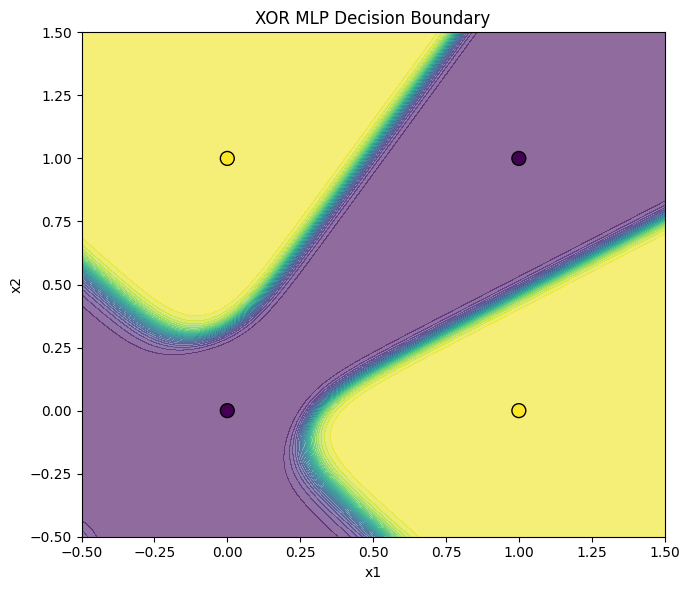

In [ ]:

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    zz = xor_model(grid).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, zz, levels=30, alpha=0.6)
plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor[:,0], edgecolors="black", s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR MLP Decision Boundary")
plt.tight_layout()
plt.savefig("p1c_xor_decision_boundary.png", dpi=200)
plt.show()


# Problem 2 — Optimization and Training Dynamics

## Part A — Optimizer Comparison

All four optimizers use the same MLP architecture and are trained for **20 epochs**, exactly as specified.


In [ ]:
optimizer_specs = {
    "SGD": lambda p: optim.SGD(p, lr=0.01),
    "SGD + Momentum": lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
    "RMSprop": lambda p: optim.RMSprop(p, lr=0.001),
    "Adam": lambda p: optim.Adam(p, lr=0.001),
}

optimizer_histories = {}
optimizer_rows = []

for name, make_opt in optimizer_specs.items():
    print("\n===", name, "===")
    set_seed(SEED)
    model = FlexibleMLP(784, [128, 64], 10, activation="relu")
    opt = make_opt(model.parameters())
    hist, _ = train_model(model, train_loader, epochs=20, optimizer=opt,
                          criterion=nn.CrossEntropyLoss(), test_loader=test_loader)
    elapsed = sum(hist["train_time"])
    optimizer_histories[name] = hist
    optimizer_rows.append({
        "Optimizer": name,
        "Final Test Accuracy": hist["test_acc"][-1],
        "Training Time (s)": elapsed
    })

optimizer_df = pd.DataFrame(optimizer_rows)
optimizer_df



=== SGD ===
Epoch 01/20 | loss=1.1621 | train_acc=0.8740 | test_acc=0.8821
Epoch 02/20 | loss=0.4032 | train_acc=0.8993 | test_acc=0.9031
Epoch 03/20 | loss=0.3258 | train_acc=0.9128 | test_acc=0.9146
Epoch 04/20 | loss=0.2884 | train_acc=0.9221 | test_acc=0.9241
Epoch 05/20 | loss=0.2617 | train_acc=0.9292 | test_acc=0.9316
Epoch 06/20 | loss=0.2404 | train_acc=0.9347 | test_acc=0.9356
Epoch 07/20 | loss=0.2228 | train_acc=0.9395 | test_acc=0.9394
Epoch 08/20 | loss=0.2076 | train_acc=0.9437 | test_acc=0.9439
Epoch 09/20 | loss=0.1943 | train_acc=0.9467 | test_acc=0.9441
Epoch 10/20 | loss=0.1826 | train_acc=0.9510 | test_acc=0.9488
Epoch 11/20 | loss=0.1720 | train_acc=0.9538 | test_acc=0.9511
Epoch 12/20 | loss=0.1622 | train_acc=0.9564 | test_acc=0.9527
Epoch 13/20 | loss=0.1535 | train_acc=0.9581 | test_acc=0.9557
Epoch 14/20 | loss=0.1459 | train_acc=0.9602 | test_acc=0.9556
Epoch 15/20 | loss=0.1386 | train_acc=0.9623 | test_acc=0.9590
Epoch 16/20 | loss=0.1322 | train_acc=0.96

,Optimizer,Final Test Accuracy,Training Time (s)
0,SGD,0.9650,51.576791
1,SGD + Momentum,0.9814,51.105876
2,RMSprop,0.9807,51.471065
3,Adam,0.9782,50.909038


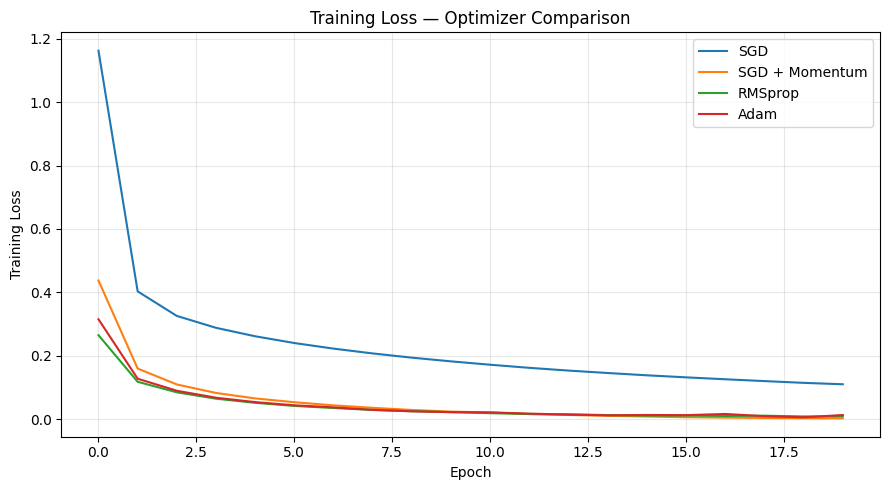

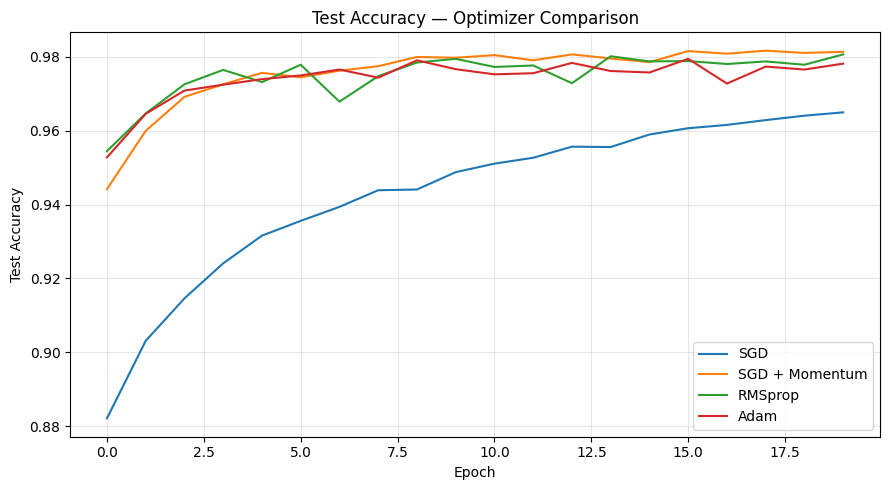

,Optimizer,Final Test Accuracy,Training Time (s)
0,SGD,0.9650,51.58
1,SGD + Momentum,0.9814,51.11
2,RMSprop,0.9807,51.47
3,Adam,0.9782,50.91


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, hist in optimizer_histories.items():
    ax.plot(hist["loss"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Loss — Optimizer Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p2a_optimizer_loss.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for name, hist in optimizer_histories.items():
    ax.plot(hist["test_acc"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy")
ax.set_title("Test Accuracy — Optimizer Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p2a_optimizer_accuracy.png", dpi=200)
plt.show()

optimizer_df.style.format({
    "Final Test Accuracy": "{:.4f}",
    "Training Time (s)": "{:.2f}"
})


### Brief analysis

Compare the curves for early convergence, final test accuracy, and elapsed training time. SGD generally makes smaller parameter updates and may converge more slowly, while momentum can accelerate movement in consistent directions. RMSprop and Adam adapt learning rates per parameter, often producing faster initial optimization. The final conclusion should be based on the measured curves and table from this run.


## Part B — Gradient Analysis

A deep MLP with six hidden layers is trained with sigmoid and ReLU activations. Mean absolute gradients of hidden-layer weights are tracked.


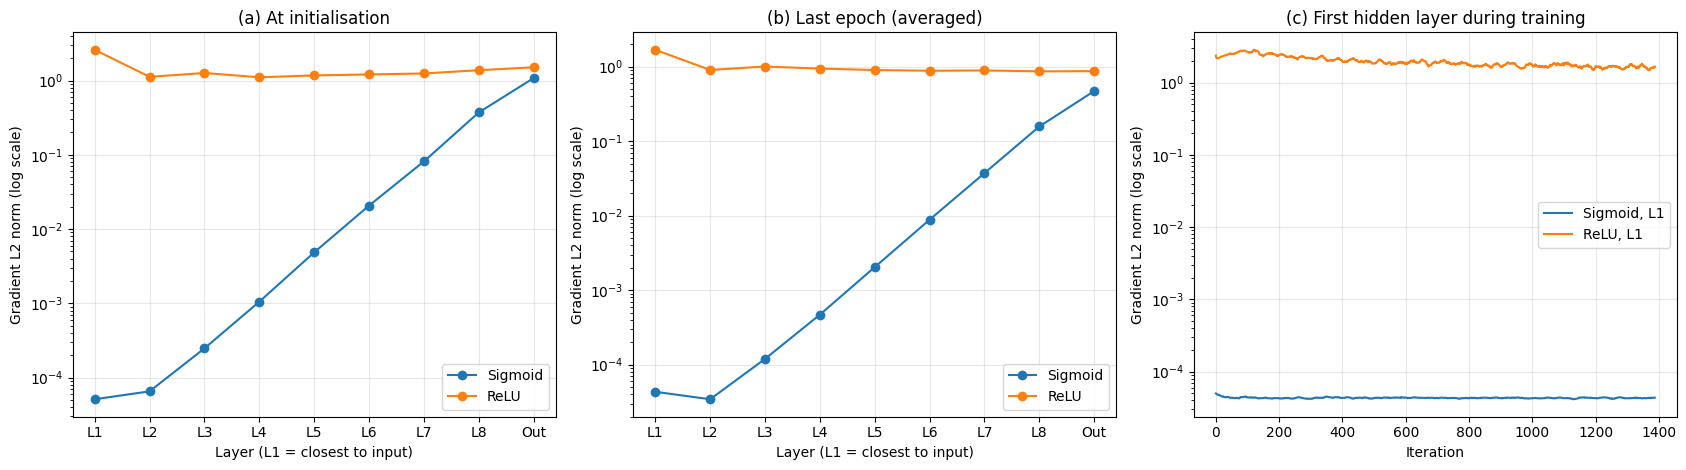

Sigmoid: grad(L1)/grad(L8) at initialisation = 1.37e-04
ReLU: grad(L1)/grad(L8) at initialisation = 1.88e+00
Final training loss  sigmoid: 2.3 | relu: 0.159


In [ ]:
N_HIDDEN, WIDTH = 8, 128

class DeepMLP(nn.Module):
    """Deep MLP; each activation is paired with its standard weight initialisation:
    sigmoid -> Xavier (Glorot), ReLU -> Kaiming (He)."""
    def __init__(self, activation="sigmoid", n_hidden=N_HIDDEN, width=WIDTH):
        super().__init__()
        act_cls = {"sigmoid": nn.Sigmoid, "relu": nn.ReLU}[activation]
        layers, prev = [nn.Flatten()], 784
        for _ in range(n_hidden):
            layers += [nn.Linear(prev, width), act_cls()]
            prev = width
        layers.append(nn.Linear(prev, 10))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                if activation == "relu":
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

def track_gradient_norms(activation, epochs=3, lr=0.01):
    """Train with SGD and record, at EVERY iteration, the L2 norm of the weight
    gradient of each Linear layer. Row 0 = gradients at initialisation."""
    set_seed(SEED)
    model = DeepMLP(activation).to(DEVICE)
    linears = [m for m in model.modules() if isinstance(m, nn.Linear)]
    opt = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    norms, losses = [], []
    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            norms.append([m.weight.grad.norm().item() for m in linears])
            losses.append(loss.item())
            opt.step()
    return np.array(norms), np.array(losses)

sig_norms, sig_losses = track_gradient_norms("sigmoid")
relu_norms, relu_losses = track_gradient_norms("relu")

iters_per_epoch = len(train_loader)
labels = [f"L{i+1}" for i in range(N_HIDDEN)] + ["Out"]
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].plot(x, sig_norms[:10].mean(0), "o-", label="Sigmoid")
axes[0].plot(x, relu_norms[:10].mean(0), "o-", label="ReLU")
axes[0].set_title("(a) At initialisation")

axes[1].plot(x, sig_norms[-iters_per_epoch:].mean(0), "o-", label="Sigmoid")
axes[1].plot(x, relu_norms[-iters_per_epoch:].mean(0), "o-", label="ReLU")
axes[1].set_title("(b) Last epoch (averaged)")

for ax in axes[:2]:
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_yscale("log"); ax.set_xlabel("Layer (L1 = closest to input)")
    ax.set_ylabel("Gradient L2 norm (log scale)")
    ax.grid(True, alpha=0.3); ax.legend()

smooth = lambda v: np.convolve(v, np.ones(20) / 20, mode="valid")
axes[2].plot(smooth(sig_norms[:, 0]), label="Sigmoid, L1")
axes[2].plot(smooth(relu_norms[:, 0]), label="ReLU, L1")
axes[2].set_yscale("log"); axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Gradient L2 norm (log scale)")
axes[2].set_title("(c) First hidden layer during training")
axes[2].grid(True, alpha=0.3); axes[2].legend()

plt.tight_layout()
plt.savefig("p2b_gradient_comparison.png", dpi=200)
plt.show()


for name, nrm in [("Sigmoid", sig_norms), ("ReLU", relu_norms)]:
    ratio = nrm[:10, 0].mean() / nrm[:10, N_HIDDEN - 1].mean()
    print(f"{name}: grad(L1)/grad(L8) at initialisation = {ratio:.2e}")
print("Final training loss  sigmoid:", sig_losses[-50:].mean().round(3), "| relu:", relu_losses[-50:].mean().round(3))


### Brief explanation

The sigmoid network is expected to show smaller gradients in earlier layers because sigmoid derivatives become small when activations saturate. This can make parameter updates in deep layers near the input very small, which is the vanishing-gradient problem. ReLU has a derivative of approximately 1 for positive inputs, so it often preserves stronger gradients through multiple layers. The plotted measurements provide the empirical comparison required by the assignment.


## Part C — Regularization Effects

Three configurations are compared:
1. baseline — no regularization
2. L2 — weight decay = 0.001
3. dropout — p = 0.5 in hidden layers



=== Baseline ===
Epoch 01/10 | loss=0.3153 | train_acc=0.9555 | test_acc=0.9528
Epoch 02/10 | loss=0.1279 | train_acc=0.9715 | test_acc=0.9646
Epoch 03/10 | loss=0.0899 | train_acc=0.9803 | test_acc=0.9709
Epoch 04/10 | loss=0.0679 | train_acc=0.9821 | test_acc=0.9725
Epoch 05/10 | loss=0.0542 | train_acc=0.9875 | test_acc=0.9740
Epoch 06/10 | loss=0.0441 | train_acc=0.9893 | test_acc=0.9750
Epoch 07/10 | loss=0.0376 | train_acc=0.9903 | test_acc=0.9766
Epoch 08/10 | loss=0.0298 | train_acc=0.9925 | test_acc=0.9744
Epoch 09/10 | loss=0.0252 | train_acc=0.9952 | test_acc=0.9791
Epoch 10/10 | loss=0.0224 | train_acc=0.9923 | test_acc=0.9767

=== L2 ===
Epoch 01/10 | loss=0.3192 | train_acc=0.9538 | test_acc=0.9530
Epoch 02/10 | loss=0.1343 | train_acc=0.9705 | test_acc=0.9652
Epoch 03/10 | loss=0.0988 | train_acc=0.9797 | test_acc=0.9727
Epoch 04/10 | loss=0.0807 | train_acc=0.9787 | test_acc=0.9688
Epoch 05/10 | loss=0.0712 | train_acc=0.9830 | test_acc=0.9746
Epoch 06/10 | loss=0.0634

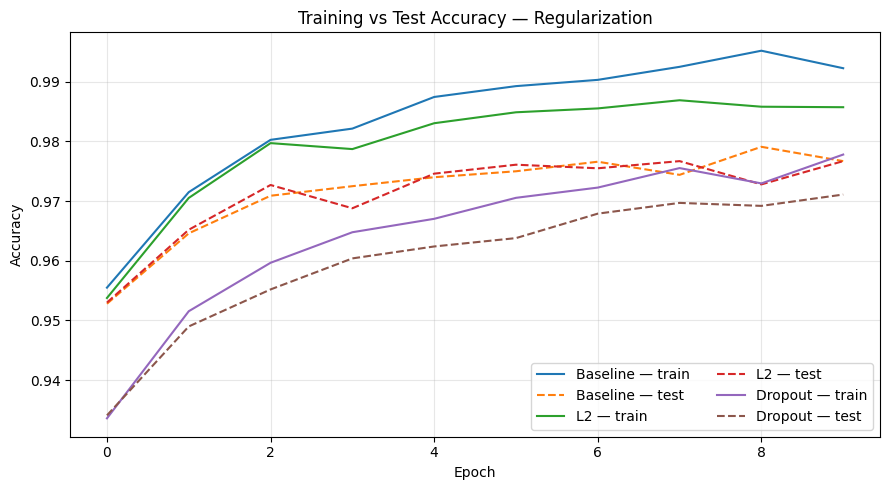

,Config,Train acc,Test acc,Gap
0,Baseline,0.9923,0.9767,0.0156
1,L2,0.9857,0.9767,0.0090
2,Dropout,0.9778,0.9711,0.0067


In [ ]:
regularization_configs = {
    "Baseline": {"weight_decay": 0.0, "dropout": 0.0},
    "L2": {"weight_decay": 0.001, "dropout": 0.0},
    "Dropout": {"weight_decay": 0.0, "dropout": 0.5}
}

reg_histories = {}

for name, cfg in regularization_configs.items():
    print("\n===", name, "===")
    set_seed(SEED)
    model = FlexibleMLP(784, [128, 64], 10, activation="relu", dropout=cfg["dropout"])
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=cfg["weight_decay"])
    hist, _ = train_model(model, train_loader, epochs=10, optimizer=opt,
                          criterion=nn.CrossEntropyLoss(), test_loader=test_loader)
    reg_histories[name] = hist

fig, ax = plt.subplots(figsize=(9, 5))
for name, hist in reg_histories.items():
    ax.plot(hist["train_acc"], label=f"{name} — train")
    ax.plot(hist["test_acc"], linestyle="--", label=f"{name} — test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training vs Test Accuracy — Regularization")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p2c_regularization.png", dpi=200)
plt.show()

gap_df = pd.DataFrame({
    "Config": list(reg_histories),
    "Train acc": [h["train_acc"][-1] for h in reg_histories.values()],
    "Test acc": [h["test_acc"][-1] for h in reg_histories.values()],
})
gap_df["Gap"] = gap_df["Train acc"] - gap_df["Test acc"]
gap_df.round(4)


### Brief analysis

Overfitting is indicated when training accuracy continues to rise while test accuracy stops improving or declines. L2 regularization constrains large weights through weight decay, while dropout randomly removes hidden activations during training and can reduce co-adaptation. Use the generated train/test curves to identify which method most effectively narrows the generalization gap in this experiment.


# Problem 3 — Convolutional Neural Networks

## Part A — Basic CNN

Required architecture:
- Conv 32, 3×3, ReLU, same padding
- MaxPool 2×2
- Conv 64, 3×3, ReLU, same padding
- MaxPool 2×2
- Flatten
- Fully connected 128, ReLU
- 10-class output

Training duration: **20 epochs**.


In [ ]:
cifar_transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
cifar_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

cifar_train = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=cifar_transform_train)
cifar_test = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=cifar_transform_test)


val_size = 5000
train_size = len(cifar_train) - val_size
train_subset, val_subset = torch.utils.data.random_split(
    cifar_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

cifar_train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
cifar_val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
cifar_test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train:", len(train_subset), "Validation:", len(val_subset), "Test:", len(cifar_test))


100%|██████████| 170M/170M [51:24<00:00, 55.3kB/s]    
/opt/miniconda3/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 45000 Validation: 5000 Test: 10000


In [ ]:
class BasicCNN(nn.Module):
    """Required architecture: Conv32-Pool-Conv64-Pool-FC128-FC10 (3x3 kernels, 'same' padding)."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def evaluate_loss_acc(model, loader, criterion):
    """Average loss and accuracy of `model` on `loader`."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

def train_cnn(model, train_loader, val_loader, epochs=20, lr=1e-3):
    """Train a CNN. The returned time counts only the optimisation loop
    (validation is excluded), so runs are comparable."""
    model.to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    h = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    train_time = 0.0

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        train_time += time.time() - t0

        tr_loss, tr_acc = total_loss / total, correct / total
        va_loss, va_acc = evaluate_loss_acc(model, val_loader, criterion)
        h["train_loss"].append(tr_loss); h["val_loss"].append(va_loss)
        h["train_acc"].append(tr_acc);   h["val_acc"].append(va_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | train_loss={tr_loss:.4f} | "
              f"val_loss={va_loss:.4f} | train_acc={tr_acc:.4f} | val_acc={va_acc:.4f}")

    return h, train_time

set_seed(SEED)
basic_cnn = BasicCNN()
basic_history, basic_time = train_cnn(basic_cnn, cifar_train_loader, cifar_val_loader, epochs=20)
test_loss, test_acc = evaluate_loss_acc(basic_cnn, cifar_test_loader, nn.CrossEntropyLoss())

best_ep = int(np.argmin(basic_history["val_loss"])) + 1
print("Final CIFAR-10 test accuracy:", test_acc)
print("Training time (s):", round(basic_time, 2))
print(f"Validation loss is lowest at epoch {best_ep} "
      f"({min(basic_history['val_loss']):.3f}) and {basic_history['val_loss'][-1]:.3f} at epoch 20 -> overfitting")


Epoch 01/20 | train_loss=1.3919 | val_loss=1.1124 | train_acc=0.5039 | val_acc=0.6064
Epoch 02/20 | train_loss=1.0115 | val_loss=0.9380 | train_acc=0.6440 | val_acc=0.6734
Epoch 03/20 | train_loss=0.8514 | val_loss=0.8879 | train_acc=0.7026 | val_acc=0.6866
Epoch 04/20 | train_loss=0.7368 | val_loss=0.8335 | train_acc=0.7428 | val_acc=0.7112
Epoch 05/20 | train_loss=0.6439 | val_loss=0.8033 | train_acc=0.7756 | val_acc=0.7226
Epoch 06/20 | train_loss=0.5543 | val_loss=0.7974 | train_acc=0.8074 | val_acc=0.7322
Epoch 07/20 | train_loss=0.4740 | val_loss=0.8241 | train_acc=0.8368 | val_acc=0.7294
Epoch 08/20 | train_loss=0.3909 | val_loss=0.9538 | train_acc=0.8652 | val_acc=0.7096
Epoch 09/20 | train_loss=0.3235 | val_loss=0.9189 | train_acc=0.8887 | val_acc=0.7190
Epoch 10/20 | train_loss=0.2539 | val_loss=0.9679 | train_acc=0.9142 | val_acc=0.7312
Epoch 11/20 | train_loss=0.2006 | val_loss=1.0737 | train_acc=0.9320 | val_acc=0.7254
Epoch 12/20 | train_loss=0.1573 | val_loss=1.1637 | tr

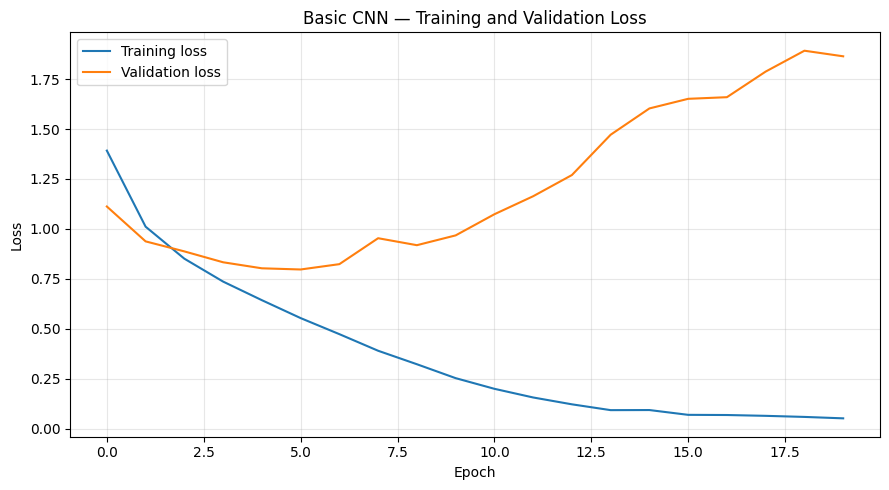

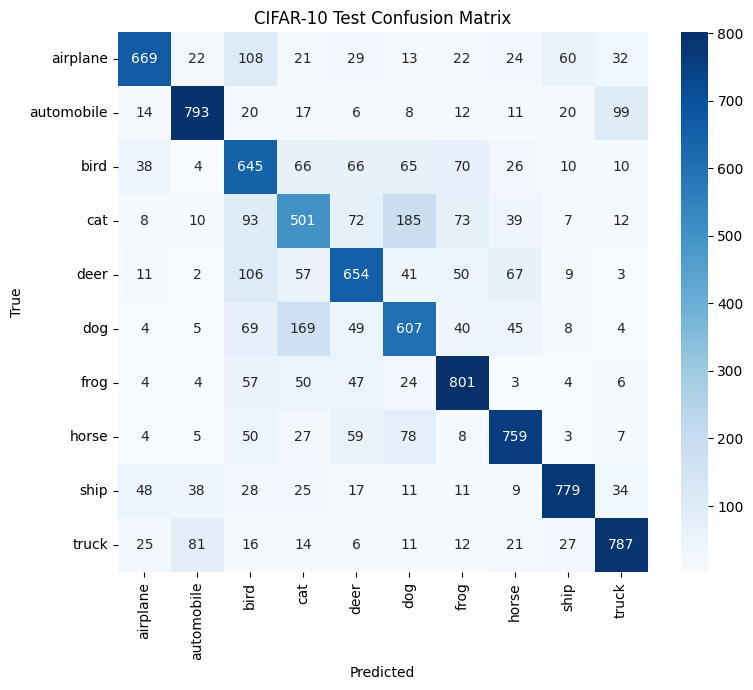

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(basic_history["train_loss"], label="Training loss")
plt.plot(basic_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Basic CNN — Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p3a_loss_curves.png", dpi=200)
plt.show()


basic_cnn.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in cifar_test_loader:
        out = basic_cnn(x.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())

classes = cifar_test.classes
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CIFAR-10 Test Confusion Matrix")
plt.tight_layout()
plt.savefig("p3a_confusion_matrix.png", dpi=200)
plt.show()


## Part B — Architecture Experimentation

Three CNNs are compared by changing convolutional depth, filter count, kernel size, and pooling strategy.


In [ ]:
# Three architectures, each different from the 3A baseline (which is added as a reference row).
class CNN_A(nn.Module):
    """A: small & shallow -- 2 conv layers, FEWER filters (16/32), bigger 5x5 kernels, max pooling."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class CNN_B(nn.Module):
    """B: deeper & wider -- 3 conv layers (32/64/128 filters), 3x3 kernels, max pooling."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class CNN_C(nn.Module):
    """C: AVERAGE pooling instead of max pooling, 5x5 kernels in the first two convs, 3 conv layers."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

architectures = {"Architecture A": CNN_A, "Architecture B": CNN_B, "Architecture C": CNN_C}

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

arch_rows = [{
    "Architecture": "Baseline (3A)",
    "Parameters": count_parameters(basic_cnn),
    "Training Time (s)": basic_time,
    "Test Accuracy": test_acc
}]
arch_histories = {}

for name, cls in architectures.items():
    print("\n===", name, "===")
    set_seed(SEED)
    model = cls()
    params = count_parameters(model)
    hist, elapsed = train_cnn(model, cifar_train_loader, cifar_val_loader, epochs=20)
    _, acc = evaluate_loss_acc(model, cifar_test_loader, nn.CrossEntropyLoss())
    arch_histories[name] = hist
    arch_rows.append({
        "Architecture": name,
        "Parameters": params,
        "Training Time (s)": elapsed,
        "Test Accuracy": acc
    })

architecture_df = pd.DataFrame(arch_rows)
architecture_df



=== Architecture A ===
Epoch 01/20 | train_loss=1.4791 | val_loss=1.2307 | train_acc=0.4715 | val_acc=0.5634
Epoch 02/20 | train_loss=1.1112 | val_loss=1.0637 | train_acc=0.6091 | val_acc=0.6310
Epoch 03/20 | train_loss=0.9606 | val_loss=0.9686 | train_acc=0.6619 | val_acc=0.6586
Epoch 04/20 | train_loss=0.8617 | val_loss=0.9066 | train_acc=0.6977 | val_acc=0.6810
Epoch 05/20 | train_loss=0.7798 | val_loss=0.8862 | train_acc=0.7281 | val_acc=0.6916
Epoch 06/20 | train_loss=0.7134 | val_loss=0.8914 | train_acc=0.7509 | val_acc=0.6924
Epoch 07/20 | train_loss=0.6448 | val_loss=0.8735 | train_acc=0.7751 | val_acc=0.6974
Epoch 08/20 | train_loss=0.5834 | val_loss=0.8739 | train_acc=0.7959 | val_acc=0.7044
Epoch 09/20 | train_loss=0.5228 | val_loss=0.8983 | train_acc=0.8173 | val_acc=0.6978
Epoch 10/20 | train_loss=0.4622 | val_loss=0.9336 | train_acc=0.8394 | val_acc=0.7014
Epoch 11/20 | train_loss=0.4093 | val_loss=0.9719 | train_acc=0.8597 | val_acc=0.6990
Epoch 12/20 | train_loss=0.367

,Architecture,Parameters,Training Time (s),Test Accuracy
0,Baseline (3A),545098,585.624198,0.6995
1,Architecture A,277610,572.577574,0.6755
2,Architecture B,1143242,1385.712222,0.7302
3,Architecture C,616330,842.253583,0.7048


### Architecture descriptions

| Model | Conv layers | Filters | Kernels | Pooling | Idea |
|---|---|---|---|---|---|
| Baseline (3A) | 2 | 32 / 64 | 3×3 | Max | required architecture, reference |
| A | 2 | 16 / 32 | 5×5 | Max | smaller and shallower: fewer parameters |
| B | 3 | 32 / 64 / 128 | 3×3 | Max | deeper and wider: more capacity |
| C | 3 | 32 / 64 / 64 | 5×5, 5×5, 3×3 | Average | average instead of max pooling |

The comparison table generated above reports the parameter count, training time, and test accuracy.


### Trade-off analysis

Increasing depth and filter count increases the number of trainable parameters and computational cost. A more complex network can learn richer hierarchical features, but the extra capacity does not automatically guarantee higher test accuracy. Kernel size and pooling also change the amount of spatial information preserved by the model. The final trade-off should therefore be discussed using the measured parameter counts, training times, and test accuracies in the generated table.


## Part C — Visualizing Learned Features

At least eight first-layer filters and activation maps for 2–3 sample images are visualized below.


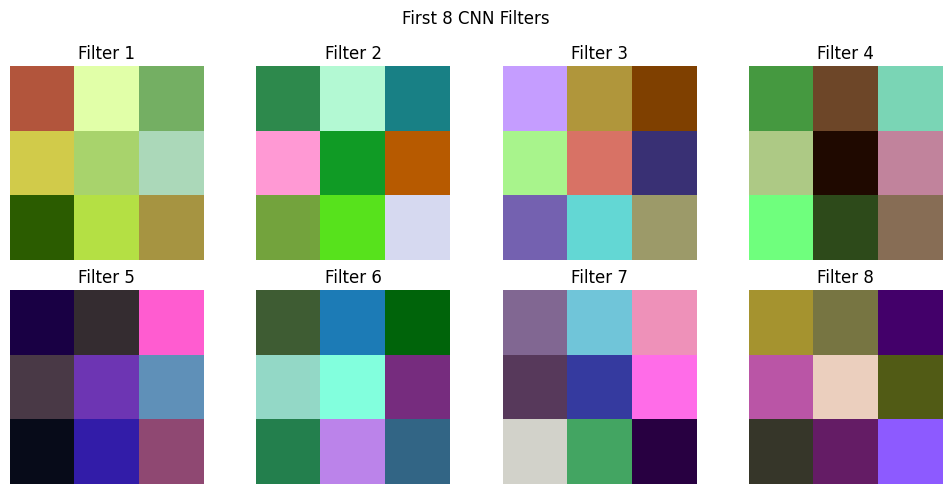

In [ ]:

weights = basic_cnn.features[0].weight.detach().cpu()

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    kernel = weights[i]

    k = kernel.permute(1, 2, 0)
    k = (k - k.min()) / (k.max() - k.min() + 1e-8)
    ax.imshow(k)
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")
plt.suptitle("First 8 CNN Filters")
plt.tight_layout()
plt.savefig("p3c_first_8_filters.png", dpi=200)
plt.show()


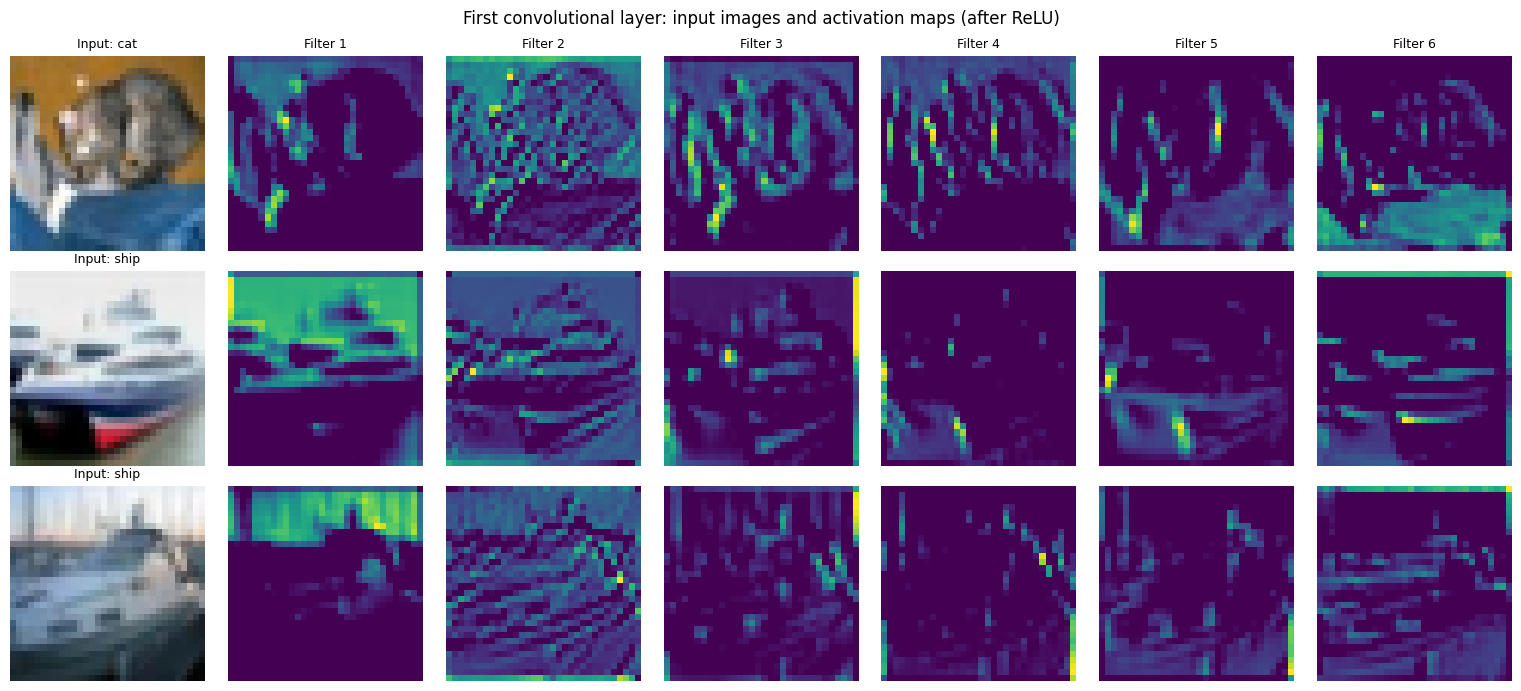

In [ ]:

basic_cnn.eval()
classes = cifar_test.classes
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
denorm = lambda img: (img.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)

samples, labels = next(iter(cifar_test_loader))
samples, labels = samples[:3].to(DEVICE), labels[:3]

with torch.no_grad():
    maps = torch.relu(basic_cnn.features[0](samples)).cpu()      # shape (3, 32, 32, 32)

n_maps = 6
fig, axes = plt.subplots(3, n_maps + 1, figsize=(2.2 * (n_maps + 1), 7))
for r in range(3):
    axes[r, 0].imshow(denorm(samples[r]))
    axes[r, 0].set_title(f"Input: {classes[labels[r]]}", fontsize=9)
    for c in range(n_maps):
        axes[r, c + 1].imshow(maps[r, c], cmap="viridis")
        if r == 0:
            axes[r, c + 1].set_title(f"Filter {c+1}", fontsize=9)
    for ax in axes[r]:
        ax.axis("off")
plt.suptitle("First convolutional layer: input images and activation maps (after ReLU)")
plt.tight_layout()
plt.savefig("p3c_activation_maps.png", dpi=200)
plt.show()
